## Process data

### Substitutions

In [1]:
import os
import pandas as pd

extract_dir = "../../../data/proteingym_dms/raw/DMS_ProteinGym_substitutions/"

summary = []

for file_name in os.listdir(extract_dir):
    if not file_name.endswith(".csv"):
        continue  

    file_path = os.path.join(extract_dir, file_name)
    try:
        df = pd.read_csv(file_path)

        if "mutated_sequence" not in df.columns or "mutant" not in df.columns:
            print(f"Skipping {file_name} (missing required columns)")
            continue

        seq_len = df["mutated_sequence"].str.len().mean()

        mutation_counts = df["mutant"].astype(str).apply(lambda x: len(x.split(":")))
        mutation_summary = mutation_counts.value_counts().sort_index()

        summary.append((file_name, round(seq_len, 1), mutation_summary))

    except Exception as e:
        print(f"Error reading {file_name}: {e}")

summary_data = []
for file_name, seq_len, mutation_summary in summary:
    row = {"file_name": file_name, "avg_sequence_length": seq_len}
    for num_mut, count in mutation_summary.items():
        row[f"{num_mut}_mut"] = count
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.fillna(0).astype({col: int for col in summary_df.columns if col.endswith("_mut")})

summary_df = summary_df.sort_values(by="avg_sequence_length")

print("\nSequence Length and Mutation Summary:\n")
print(summary_df.to_string(index=False))



Sequence Length and Mutation Summary:

                                      file_name  avg_sequence_length  1_mut  2_mut  3_mut  4_mut  5_mut  6_mut  7_mut  8_mut  9_mut  10_mut  11_mut  12_mut  13_mut  14_mut  15_mut  16_mut  17_mut  18_mut  19_mut  20_mut  21_mut  22_mut  23_mut  24_mut  25_mut  26_mut  27_mut  28_mut  29_mut  31_mut  32_mut  33_mut  34_mut  35_mut  36_mut  37_mut  38_mut  39_mut  40_mut  41_mut  42_mut  43_mut  44_mut
            TCRG1_MOUSE_Tsuboyama_2023_1E0L.csv                 37.0    621    437      0      0      0      0      0      0      0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0       0
             PIN1_HUMAN_Tsuboyama_2023_1I6C.csv                 39.0    686    116      0      0      0      0      0      0      0       0       0     


File: YNZC_BACSU_Tsuboyama_2023_2JVD.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 2300
mutant
1     714
2    1586
Name: count, dtype: int64
Sequence length: 39.0
Proportion better than cut-off: 0.247


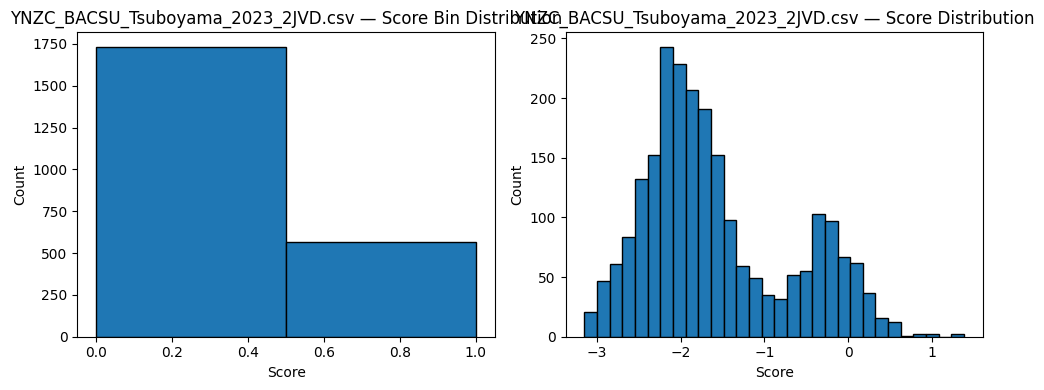

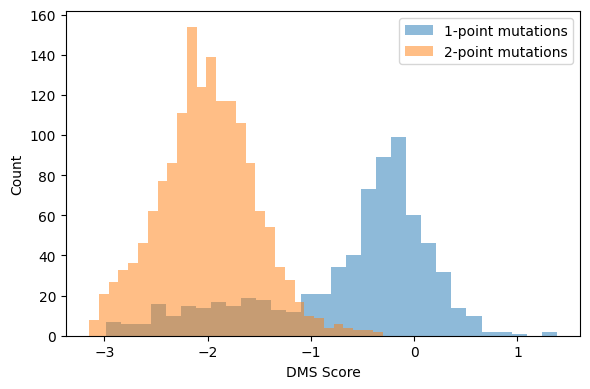

Unique sequences: 2300 (100.00%)

File: MAFG_MOUSE_Tsuboyama_2023_1K1V.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 1429
mutant
1    762
2    667
Name: count, dtype: int64
Sequence length: 41.0
Proportion better than cut-off: 0.341


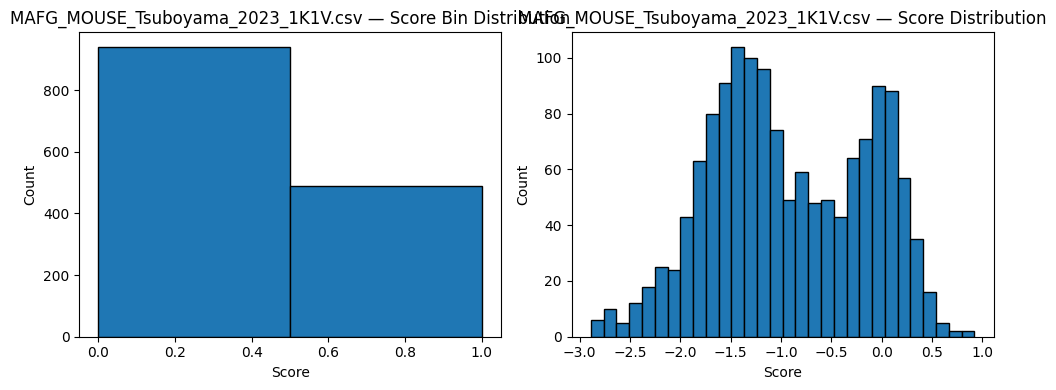

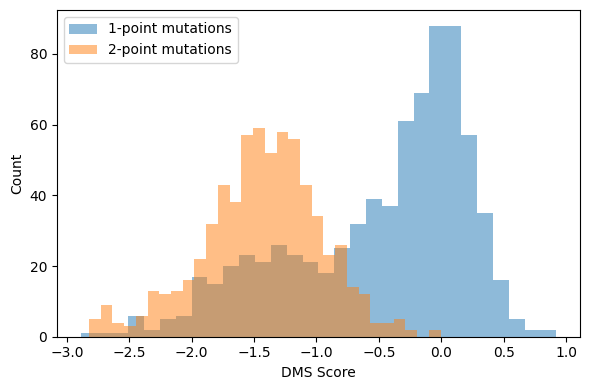

Unique sequences: 1429 (100.00%)

File: SDA_BACSU_Tsuboyama_2023_1PV0.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 2770
mutant
1     834
2    1936
Name: count, dtype: int64
Sequence length: 44.0
Proportion better than cut-off: 0.232


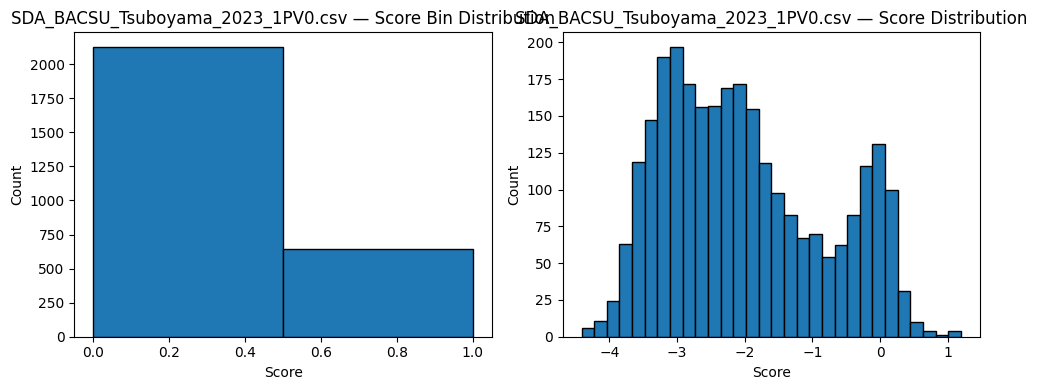

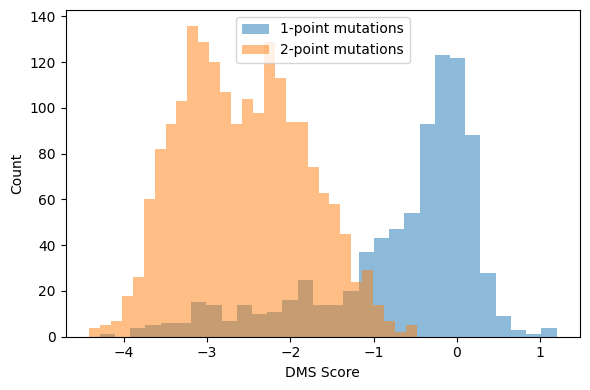

Unique sequences: 2770 (100.00%)

File: POLG_PESV_Tsuboyama_2023_2MXD.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 5130
mutant
1     995
2    4135
Name: count, dtype: int64
Sequence length: 53.0
Proportion better than cut-off: 0.275


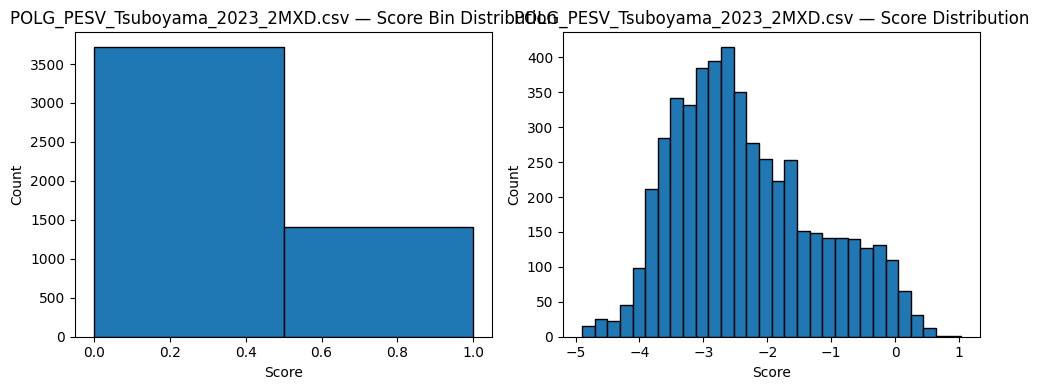

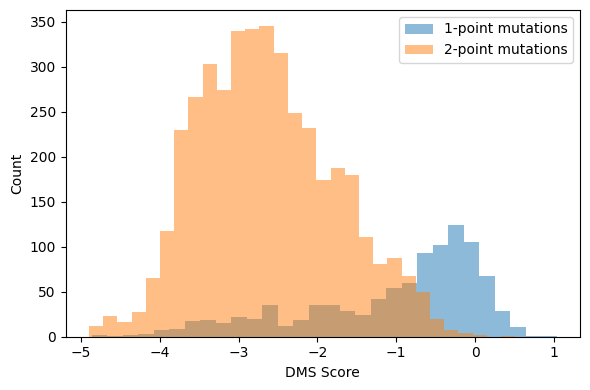

Unique sequences: 5130 (100.00%)

File: DN7A_SACS2_Tsuboyama_2023_1JIC.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 1008
mutant
1    1008
Name: count, dtype: int64
Sequence length: 55.0
Proportion better than cut-off: 0.497


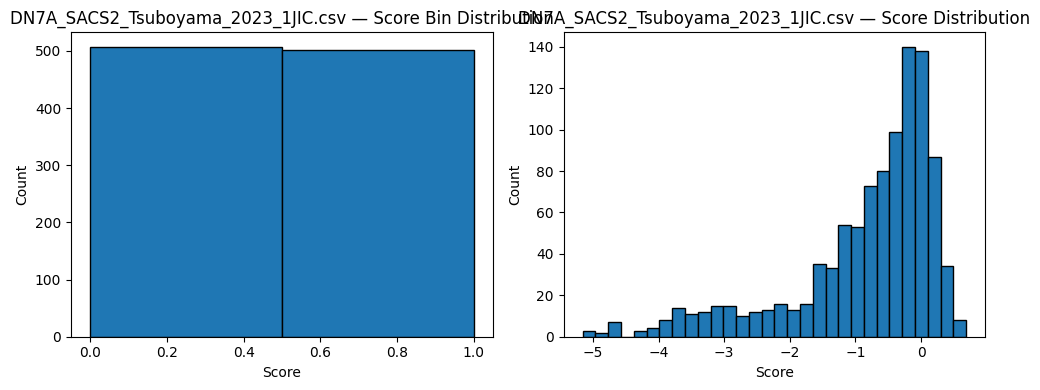

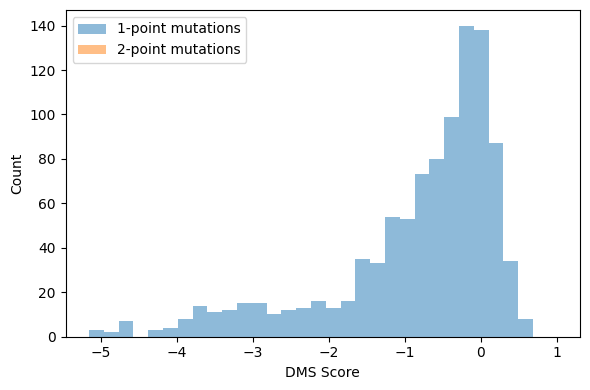

Unique sequences: 1008 (100.00%)

File: SBI_STAAM_Tsuboyama_2023_2JVG.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 1025
mutant
1    1025
Name: count, dtype: int64
Sequence length: 56.0
Proportion better than cut-off: 0.498


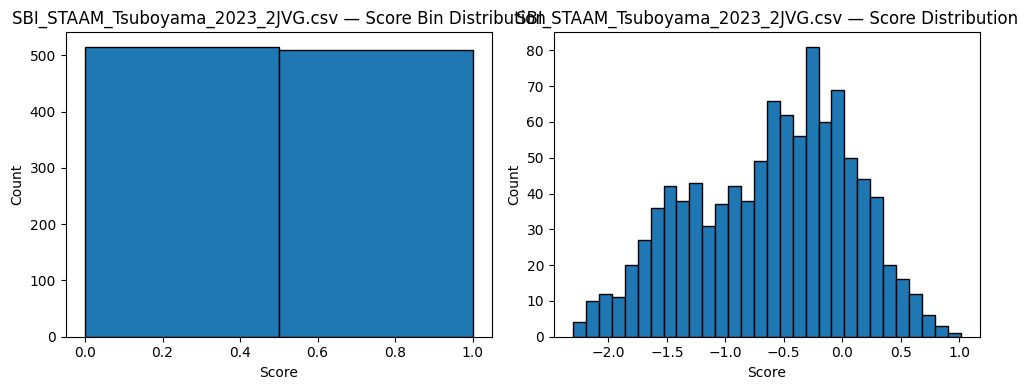

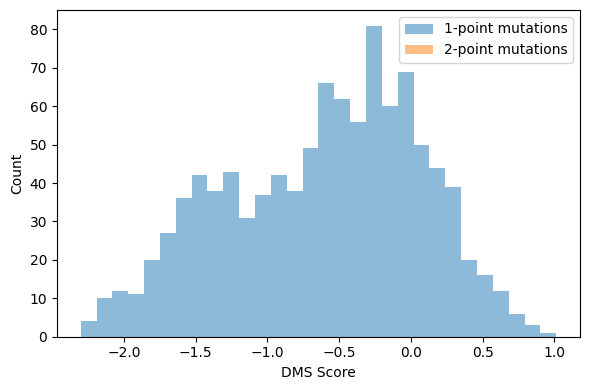

Unique sequences: 1025 (100.00%)

File: SOX30_HUMAN_Tsuboyama_2023_7JJK.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 1010
mutant
1    1010
Name: count, dtype: int64
Sequence length: 57.0
Proportion better than cut-off: 0.497


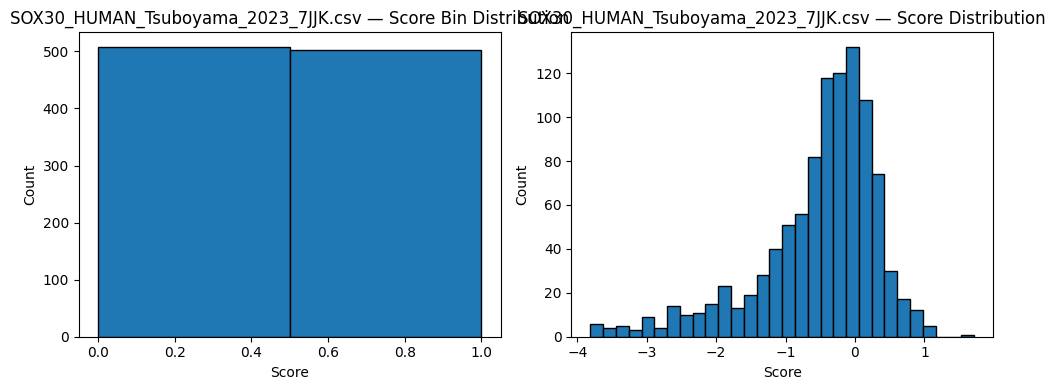

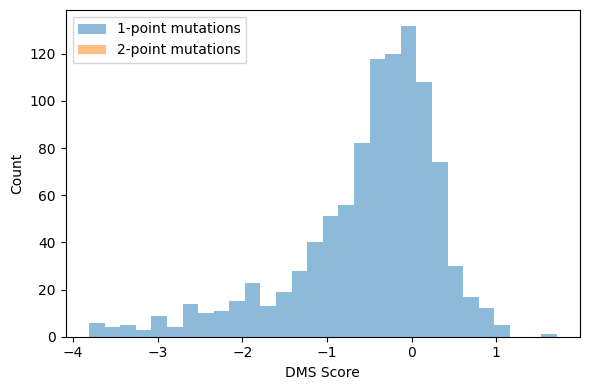

Unique sequences: 1010 (100.00%)

File: ENVZ_ECOLI_Ghose_2023.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 1121
mutant
1    1121
Name: count, dtype: int64
Sequence length: 60.0
Proportion better than cut-off: 0.641


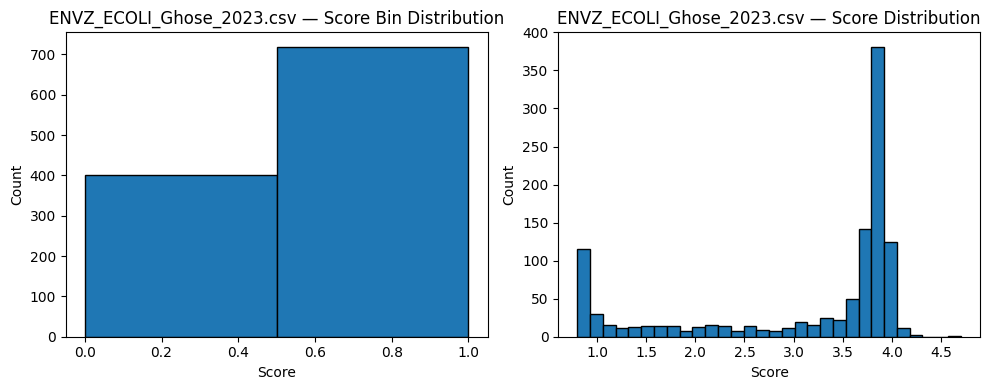

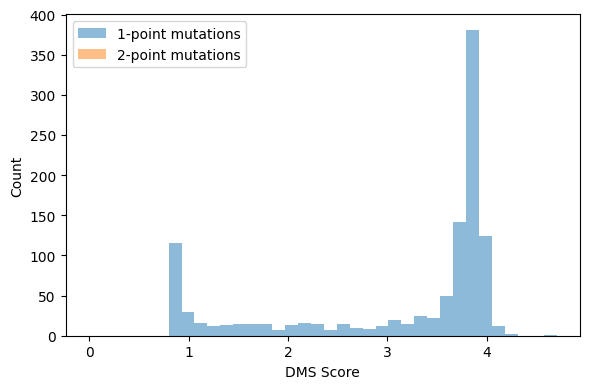

Unique sequences: 1121 (100.00%)

File: FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 1237
mutant
1    1237
Name: count, dtype: int64
Sequence length: 69.0
Proportion better than cut-off: 0.498


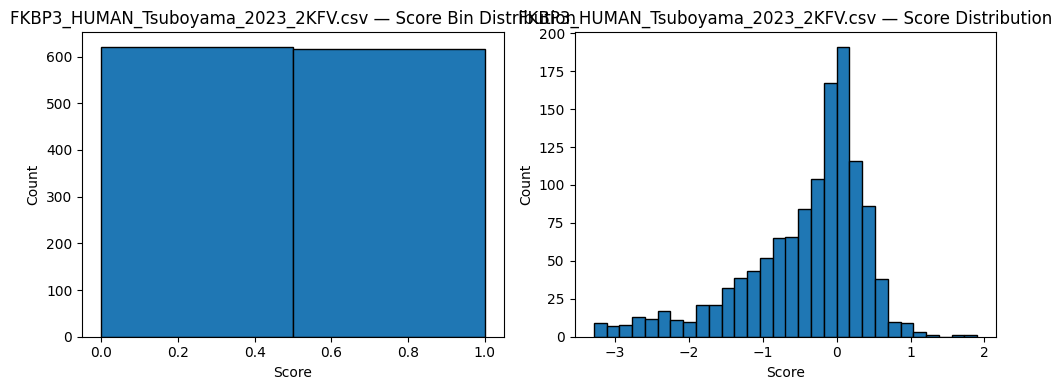

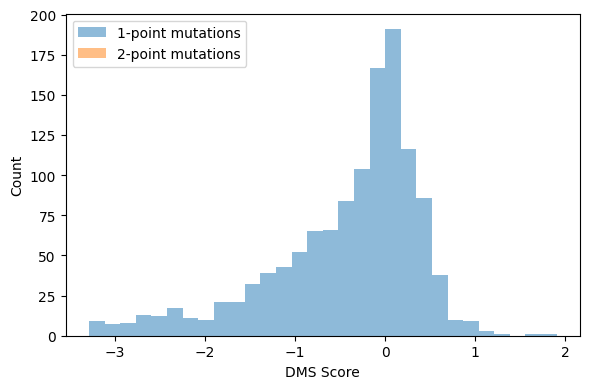

Unique sequences: 1237 (100.00%)

File: A0A247D711_LISMN_Stadelmann_2021.csv
Columns: ['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 1653
mutant
1    1653
Name: count, dtype: int64
Sequence length: 87.0
Proportion better than cut-off: 0.500


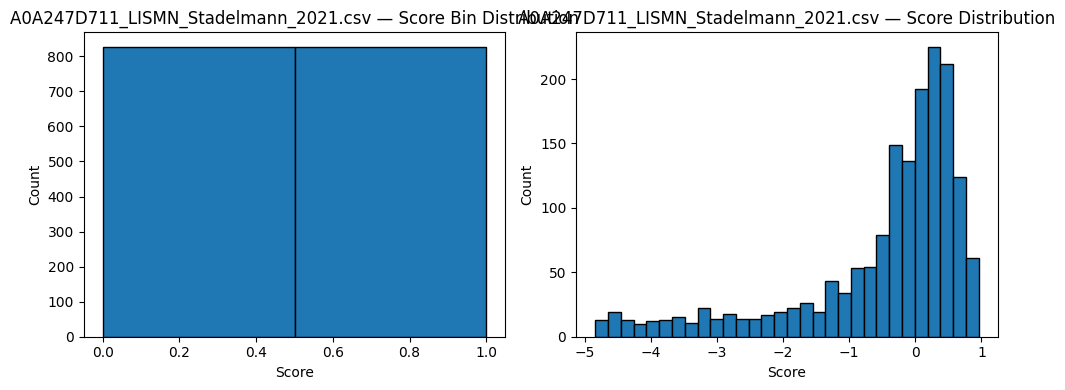

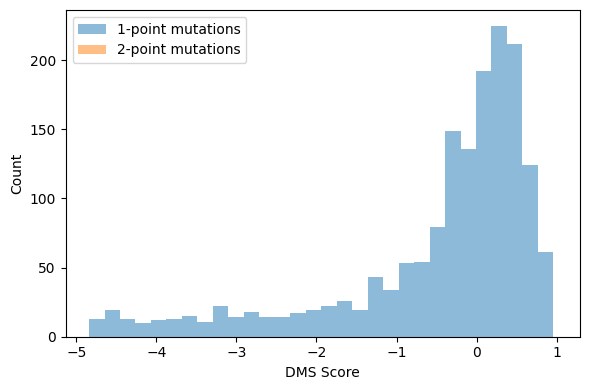

Unique sequences: 1653 (100.00%)


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


extract_dir = "../../../data/proteingym_dms/raw/DMS_ProteinGym_substitutions/"  
out_dir = "../../../data/proteingym_dms/processed/substitutions/"  
files_to_process = [
    "YNZC_BACSU_Tsuboyama_2023_2JVD.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD.csv",
    "DN7A_SACS2_Tsuboyama_2023_1JIC.csv",
    "SBI_STAAM_Tsuboyama_2023_2JVG.csv",
    "SOX30_HUMAN_Tsuboyama_2023_7JJK.csv",
    "ENVZ_ECOLI_Ghose_2023.csv",
    "FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv",
    "A0A247D711_LISMN_Stadelmann_2021.csv"
]

for file_name in files_to_process:
    file_path = os.path.join(extract_dir, file_name)
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_name}")
        continue
    
    df = pd.read_csv(file_path)
    print(f"\nFile: {file_name}")
    print(f"Columns: {list(df.columns)}")
    print(f"Total mutants: {len(df)}")

    # Count how many mutations each mutant has
    mutation_counts = df["mutant"].astype(str).apply(lambda x: len(x.split(":")))
    mutation_summary = mutation_counts.value_counts().sort_index()
    print(mutation_summary)
    
    avg_len = df["mutated_sequence"].str.len().mean()
    print(f"Sequence length: {avg_len:.1f}")

    # proportion above DMS cut-off (assuming 1 = beneficial)
    print(f"Proportion better than cut-off: {len(df[df['DMS_score_bin']==1])/len(df):.3f}")
    
    # ------------------------
    # Plot distribution of score bin + score
    # ------------------------
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(df["DMS_score_bin"], bins=2, edgecolor='black')
    plt.title(f"{file_name} — Score Bin Distribution")
    plt.xlabel("Score")
    plt.ylabel("Count")
    
    plt.subplot(1,2,2)
    plt.hist(df["DMS_score"], bins=30, edgecolor='black')
    plt.title(f"{file_name} — Score Distribution")
    plt.xlabel("Score")
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()

    # ------------------------
    # Overlaid mutation score distributions
    # ------------------------
    one_mut = df[mutation_counts == 1]["DMS_score"]
    two_mut = df[mutation_counts == 2]["DMS_score"]

    if len(one_mut) > 0 or len(two_mut) > 0:
        plt.figure(figsize=(6,4))
        
        plt.hist(one_mut, bins=30, alpha=0.5, label="1-point mutations")
        plt.hist(two_mut, bins=30, alpha=0.5, label="2-point mutations")
        
        #plt.title(f"{file_name} — Mutation Score Distributions")
        plt.xlabel("DMS Score")
        plt.ylabel("Count")
        plt.legend()
        
        plt.tight_layout()
        plt.show()

    # ------------------------
    # Save cleaned
    # ------------------------
    df.rename(columns={"mutated_sequence": "sequence", "DMS_score": "score"}, inplace=True)
    filtered_df = df[["sequence", "mutant", "score"]].copy()

    output_path = os.path.join(out_dir, file_name)
    filtered_df.to_csv(output_path, index=False)
    print(f"Saved cleaned file to: {output_path}")


### Indels

In [17]:
import os
import pandas as pd
from Levenshtein import distance as levenshtein_distance  # pip install python-Levenshtein

extract_dir = "../../../data/proteingym_dms/raw/DMS_ProteinGym_indels/"
meta_file = "../../../data/proteingym_dms/raw//DMS_indels.csv"

try:
    meta_df = pd.read_csv(meta_file)
except FileNotFoundError:
    raise FileNotFoundError(f"Metadata file not found at: {meta_file}")

required_meta_cols = {"DMS_id", "target_seq", "seq_len"}
if not required_meta_cols.issubset(meta_df.columns):
    raise ValueError(f"Metadata file missing columns: {required_meta_cols - set(meta_df.columns)}")

wt_lookup = meta_df.set_index("DMS_id")["target_seq"].to_dict()
len_lookup = meta_df.set_index("DMS_id")["seq_len"].to_dict()

summary = []

for file_name in os.listdir(extract_dir):
    if not file_name.endswith(".csv"):
        continue

    file_path = os.path.join(extract_dir, file_name)
    dms_id = file_name.replace(".csv", "")  

    WT_SEQUENCE = wt_lookup.get(dms_id, None)
    WT_LENGTH = len_lookup.get(dms_id, None)

    if WT_SEQUENCE is None:
        print(f"Skipping {file_name}: No WT info found in metadata.")
        continue

    try:
        df = pd.read_csv(file_path)

        required_cols = {"mutated_sequence", "DMS_score", "DMS_score_bin"}
        if not required_cols.issubset(df.columns):
            print(f"Skipping {file_name}: Missing columns {required_cols - set(df.columns)}")
            continue

        df["lev_distance"] = df["mutated_sequence"].apply(lambda seq: levenshtein_distance(seq, WT_SEQUENCE))

        avg_len = df["mutated_sequence"].str.len().mean()
        avg_lev = df["lev_distance"].mean()
        median_lev = df["lev_distance"].median()

        distance_counts = df["lev_distance"].value_counts().sort_index()
        distance_summary = {f"dist_{int(d)}": c for d, c in distance_counts.items()}

        row = {
            "file_name": file_name,
            "WT_length": WT_LENGTH,
            "avg_sequence_length": round(avg_len, 1),
            "avg_lev_distance": round(avg_lev, 2),
            "median_lev_distance": round(median_lev, 2),
        }
        row.update(distance_summary)
        summary.append(row)

    except Exception as e:
        print(f"Error reading {file_name}: {e}")

summary_df = pd.DataFrame(summary).fillna(0)

summary_df = summary_df.sort_values(by="WT_length")

print("\nLevenshtein Distance Summary by File:\n")
print(summary_df.to_string(index=False))




Levenshtein Distance Summary by File:

                                 file_name  WT_length  avg_sequence_length  avg_lev_distance  median_lev_distance  dist_1  dist_2  dist_3  dist_4  dist_5  dist_6  dist_7  dist_8  dist_9  dist_10  dist_11  dist_12  dist_13  dist_14  dist_15  dist_16  dist_17  dist_18  dist_19  dist_20  dist_21  dist_22  dist_23  dist_24  dist_25  dist_26  dist_27  dist_28  dist_29  dist_30  dist_31  dist_32  dist_33  dist_34  dist_35  dist_36  dist_37  dist_38  dist_39  dist_41  dist_42  dist_43  dist_44  dist_45  dist_46  dist_47  dist_48  dist_49  dist_50  dist_51  dist_52  dist_53  dist_55  dist_57  dist_58  dist_59  dist_60  dist_61  dist_62  dist_63  dist_64  dist_65  dist_66  dist_67  dist_68  dist_69  dist_70  dist_71  dist_72  dist_73  dist_74  dist_75  dist_76  dist_77  dist_78  dist_79  dist_80  dist_81  dist_82
TCRG1_MOUSE_Tsuboyama_2023_1E0L_indels.csv         37                 37.4              1.00                  1.0    99.0     0.0     0.0     0.


File: PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 187
Mean Sequence length: 71.3
WT Sequence length: 71.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.2887700534759358


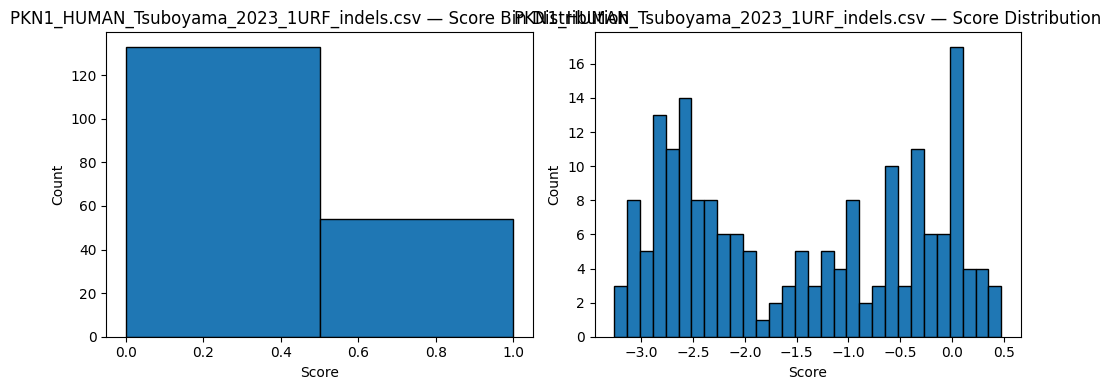

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv

File: RPC1_BP434_Tsuboyama_2023_1R69_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 164
Mean Sequence length: 61.4
WT Sequence length: 61.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.18902439024390244


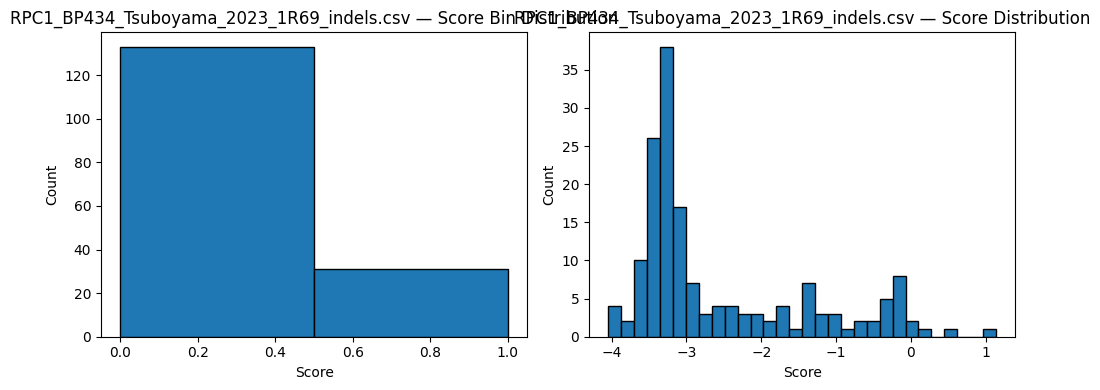

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/RPC1_BP434_Tsuboyama_2023_1R69_indels.csv

File: POLG_PESV_Tsuboyama_2023_2MXD_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 149
Mean Sequence length: 53.3
WT Sequence length: 53.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.3221476510067114


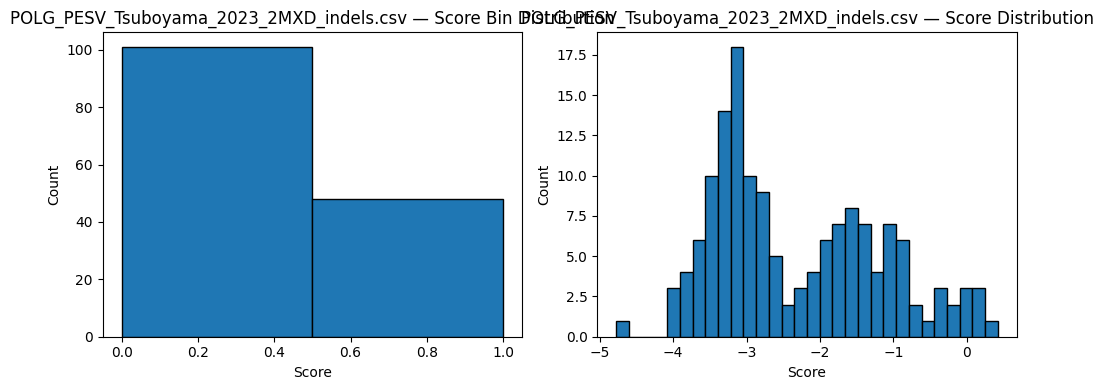

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/POLG_PESV_Tsuboyama_2023_2MXD_indels.csv

File: SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 127
Mean Sequence length: 44.4
WT Sequence length: 44.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.29133858267716534


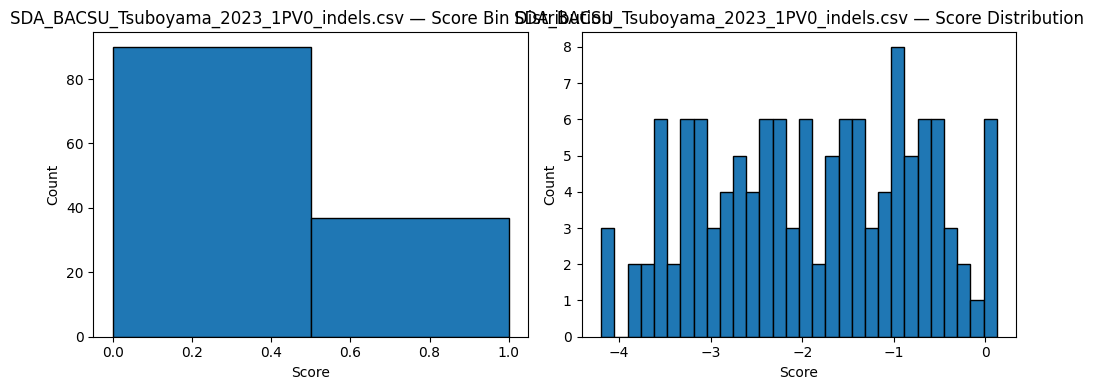

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv

File: RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 120
Mean Sequence length: 44.4
WT Sequence length: 44.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.19166666666666668


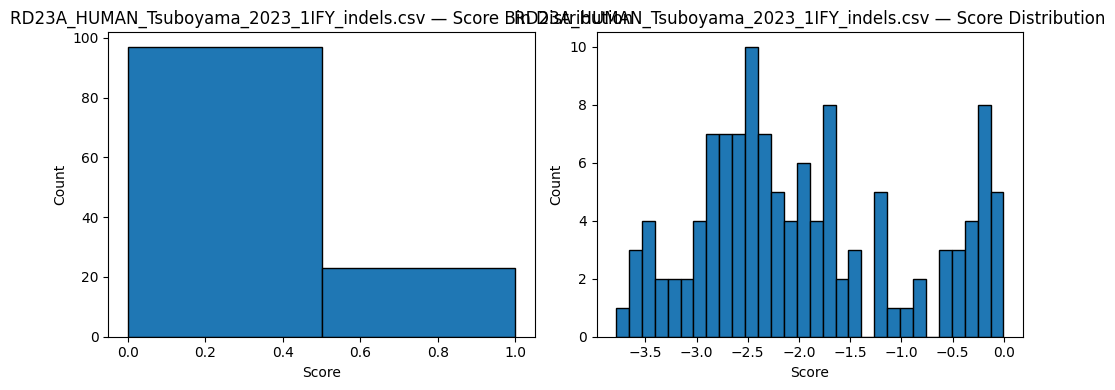

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv

File: MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 115
Mean Sequence length: 41.4
WT Sequence length: 41.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.09565217391304348


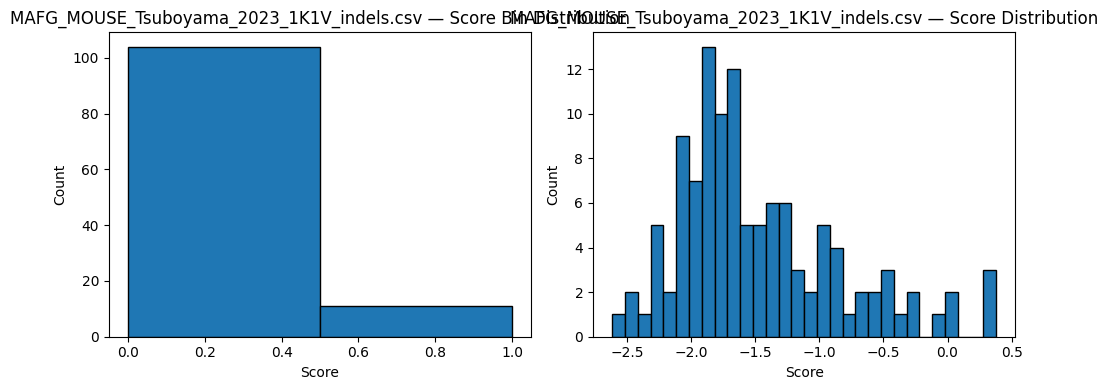

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv

File: SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 111
Mean Sequence length: 40.3
WT Sequence length: 40.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.14414414414414414


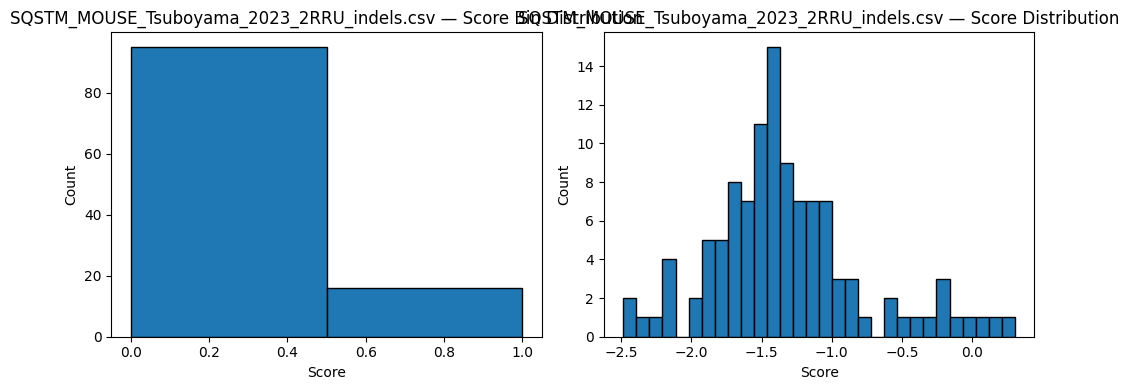

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv

File: VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 101
Mean Sequence length: 40.3
WT Sequence length: 40.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.31683168316831684


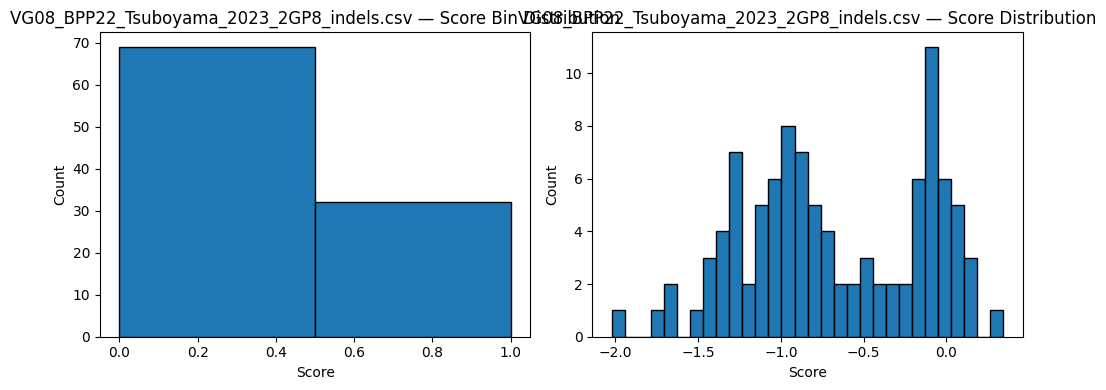

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv

File: YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 104
Mean Sequence length: 39.3
WT Sequence length: 39.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.3557692307692308


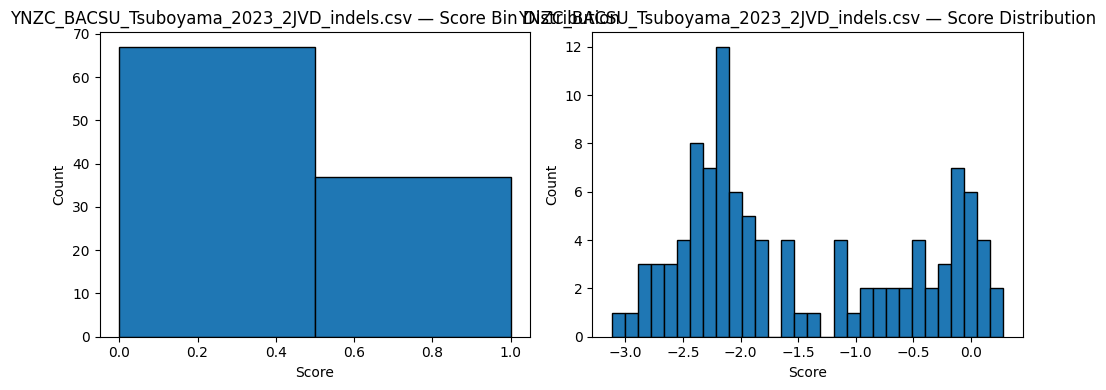

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv

File: PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv
Columns: ['mutated_sequence', 'DMS_score', 'DMS_score_bin']
Total mutants: 106
Mean Sequence length: 39.4
WT Sequence length: 39.0
Mean Levenshtein distance: 1.0
Proportion of sequences better than the DMS cut-off: 0.2830188679245283


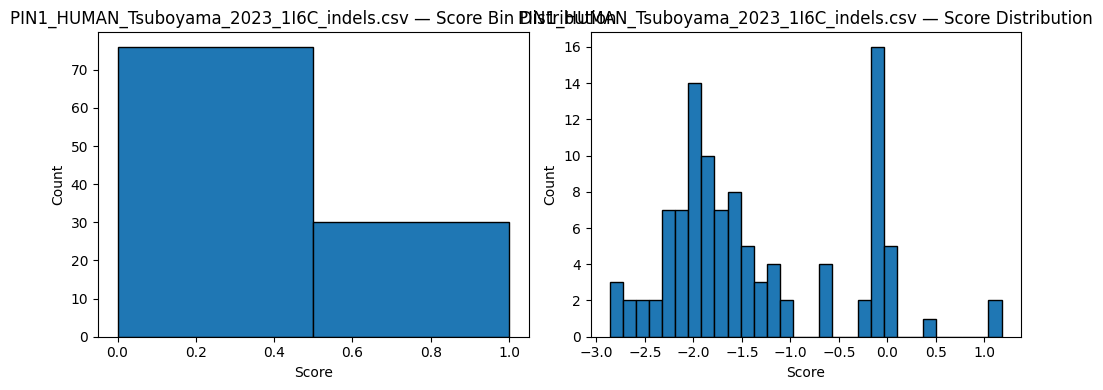

Saved cleaned file to: ../../../data/proteingym_dms/processed/indels/PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv


In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt


extract_dir = "../../../data/proteingym_dms/raw/DMS_ProteinGym_indels/"   
out_dir = "../../../data/proteingym_dms/processed/indels/"   
files_to_process = [
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv",
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv",
]

for file_name in files_to_process:
    file_path = os.path.join(extract_dir, file_name)
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_name}")
        continue
    
    df = pd.read_csv(file_path)
    print(f"\nFile: {file_name}")
    print(f"Columns: {list(df.columns)}")
    print(f"Total mutants: {len(df)}")

    dms_id = file_name.replace(".csv", "")  

    WT_SEQUENCE = wt_lookup.get(dms_id, None)
    WT_LENGTH = len_lookup.get(dms_id, None)
    df["lev_distance"] = df["mutated_sequence"].apply(lambda seq: levenshtein_distance(seq, WT_SEQUENCE))

    avg_lev = df["lev_distance"].mean()
    
    avg_len = df["mutated_sequence"].str.len().mean()
    print(f"Mean Sequence length: {avg_len:.1f}")
    print(f"WT Sequence length: {WT_LENGTH:.1f}")
    print(f"Mean Levenshtein distance: {avg_lev:.1f}")

    print(f"Proportion of sequences better than the DMS cut-off: {len(df[df["DMS_score_bin"]==1])/len(df)}")
    
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(df["DMS_score_bin"], bins=2, edgecolor='black')
    plt.title(f"{file_name} — Score Bin Distribution")
    plt.xlabel("Score")
    plt.ylabel("Count")
    
    plt.subplot(1,2,2)
    plt.hist(df["DMS_score"], bins=30, edgecolor='black')
    plt.title(f"{file_name} — Score Distribution")
    plt.xlabel("Score")
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()

    df.rename(columns={"mutated_sequence": "sequence"}, inplace=True)
    df.rename(columns={"DMS_score": "score"}, inplace=True)
    columns_to_keep = ["sequence", "score"]
    filtered_df = df[columns_to_keep].copy()

    output_path = os.path.join(out_dir, file_name)

    filtered_df.to_csv(output_path, index=False)
    print(f"Saved cleaned file to: {output_path}")



## AMPs

### MBC Dataset / Short AMPs against Escherichia coli

Median : 32.0

File: EC.csv
Columns: ['ID', 'SEQUENCE', 'EC_MIC', 'EC_pMIC', 'sequence_length', 'classes']
Total sequences: 1212
Sequence length: 14.7
Sequence length_min: 5.0


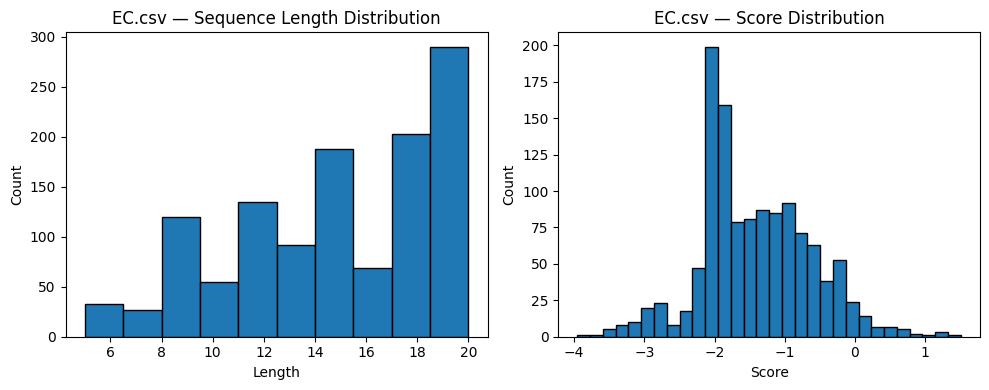

Saved cleaned file to: ../../../data/mbc/processed/EC.csv


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Levenshtein import distance as levenshtein_distance


extract_dir = "../../../data/mbc/raw/"  
out_dir = "../../../data/mbc/processed/"  

file_name = "EC.csv"
file_path = os.path.join(extract_dir, file_name)

if not os.path.exists(file_path):
    print(f"File not found: {file_name}")

df = pd.read_csv(file_path)
df = df[df["SEQUENCE"].str.len() <= 20].copy()
df["sequence_length"] = [len(i) for i in df["SEQUENCE"]]

def deduplicate_sequences_levenshtein(df, seq_col="SEQUENCE", max_distance=2):
    keep_mask = []
    kept_sequences = []

    for seq in df[seq_col]:
        is_duplicate = False
        for kept in kept_sequences:
            if levenshtein_distance(seq, kept) <= max_distance:
                is_duplicate = True
                break
        keep_mask.append(not is_duplicate)
        if not is_duplicate:
            kept_sequences.append(seq)

    return df[keep_mask].reset_index(drop=True)

# Remove sequences that are very similar
df = deduplicate_sequences_levenshtein(df)

median_score = np.median(df["EC_MIC"])
print("Median :", median_score)

# Make classes
df["classes"] = df["EC_MIC"].apply(
    lambda x: (
        "Low MIC" if x < median_score 
        #else "Medium MIC" if x < 100 
        else "High MIC" if pd.notna(x) 
        else np.nan
    )
)

print(f"\nFile: {file_name}")
print(f"Columns: {list(df.columns)}")
print(f"Total sequences: {len(df)}")

avg_len = df["SEQUENCE"].str.len().mean()
print(f"Sequence length: {avg_len:.1f}")
print(f"Sequence length_min: {df["SEQUENCE"].str.len().min():.1f}")

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.hist(df["SEQUENCE"].str.len(), bins=10, edgecolor='black')
plt.title(f"{file_name} — Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")


plt.subplot(1,2,2)
plt.hist(df["EC_pMIC"], bins=30, edgecolor='black')
plt.title(f"{file_name} — Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

df.rename(columns={"SEQUENCE": "sequence"}, inplace=True)
df.rename(columns={"EC_pMIC": "score"}, inplace=True)
columns_to_keep = ["sequence", "sequence_length", "score", "classes"]
filtered_df = df[columns_to_keep].copy()


output_path = os.path.join(out_dir, file_name)

filtered_df.to_csv(output_path, index=False)
print(f"Saved cleaned file to: {output_path}")



#### Test to strategically split the data into train and test data based on sequence similarity

{20: 88, 18: 50, 15: 42, 13: 38, 9: 36, 14: 36, 17: 34, 19: 31, 12: 30, 16: 28, 11: 26, 10: 23, 8: 13, 7: 11, 6: 10, 5: 4}
{20: 18, 18: 10, 15: 8, 13: 8, 9: 7, 14: 7, 17: 7, 19: 6, 12: 6, 16: 6, 11: 5, 10: 4, 8: 3, 7: 2, 6: 2, 5: 1}
Test set size: 500 (expected 500)
Train set size: 100 (expected 100)


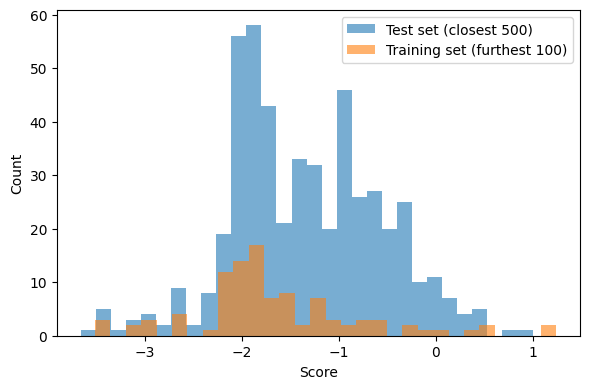

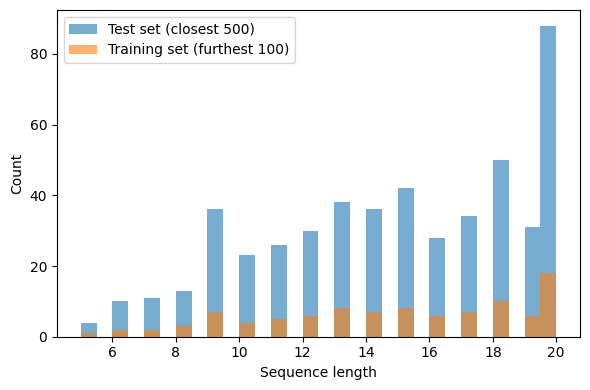

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Levenshtein import distance as levenshtein_distance

# ------------------------
# PARAMETERS
# ------------------------
random_seed = 42
total_test_size = 500  
total_train_size = 100 

# ------------------------
# Load data
# ------------------------
out_dir = "../../../data/mbc/processed/"  
output_file = "EC.csv"
file_path = os.path.join(out_dir, output_file)
df = pd.read_csv(file_path)

# Ensure sequence_length column exists
if "sequence_length" not in df.columns:
    df["sequence_length"] = df["sequence"].apply(len)

# ------------------------
# Compute sequence length proportions
# ------------------------
length_counts = df["sequence_length"].value_counts()
length_proportions = length_counts / len(df)

# ------------------------
# Compute exact counts per length with rounding
# ------------------------
def allocate_counts(total_size, proportions):
    raw_counts = proportions * total_size
    
    floored_counts = np.floor(raw_counts).astype(int)
    
    remainder = total_size - floored_counts.sum()

    fractional_parts = raw_counts - floored_counts
    
    indices_to_increment = np.argsort(-fractional_parts.values)[:remainder]
    
    for pos in indices_to_increment:
        floored_counts.iloc[pos] += 1
        
    return floored_counts.to_dict()

test_counts = allocate_counts(total_test_size, length_proportions)
print(test_counts)
train_counts = allocate_counts(total_train_size, length_proportions)
print(train_counts)

# ------------------------
# Initialize random generator
# ------------------------
rng = np.random.default_rng(random_seed)

test_indices = []
train_indices = []

# ------------------------
# Select sequences per length
# ------------------------
for seq_len in length_proportions.index:
    subset = df[df["sequence_length"] == seq_len].copy()
    if len(subset) == 0:
        continue
    
    # Number of test/train samples for this length
    test_n = min(test_counts.get(seq_len, 0), len(subset))
    train_n = min(train_counts.get(seq_len, 0), len(subset) - test_n)
    
    if test_n + train_n == 0:
        continue
    
    # Pick a reference sequence randomly from this length
    ref_idx = rng.choice(subset.index)
    ref_seq = subset.loc[ref_idx, "sequence"]
    
    # Compute Levenshtein distances
    subset["lev_distance"] = subset["sequence"].apply(
        lambda s: levenshtein_distance(ref_seq, s)
    )
    
    # Test: closest sequences
    test_subset = subset.sort_values("lev_distance", ascending=True).head(test_n)
    test_indices.extend(test_subset.index.tolist())
    
    # Training: furthest sequences from remaining
    remaining_subset = subset.drop(index=test_subset.index)
    train_subset = remaining_subset.sort_values("lev_distance", ascending=False).head(train_n)
    train_indices.extend(train_subset.index.tolist())

# ------------------------
# Create test and training DataFrames
# ------------------------
test_df = df.loc[test_indices].copy()
train_df = df.loc[train_indices].copy()

print(f"Test set size: {len(test_df)} (expected {total_test_size})")
print(f"Train set size: {len(train_df)} (expected {total_train_size})")

# ------------------------
# Visualizations
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(test_df["score"], bins=30, alpha=0.6, label=f"Test set (closest {len(test_df)})")
plt.hist(train_df["score"], bins=30, alpha=0.6, label=f"Training set (furthest {len(train_df)})")
plt.xlabel("Score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(test_df["sequence_length"], bins=30, alpha=0.6, label=f"Test set (closest {len(test_df)})")
plt.hist(train_df["sequence_length"], bins=30, alpha=0.6, label=f"Training set (furthest {len(train_df)})")
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## CellPPD - cell penetrating peptides (CPPs)

Saved cleaned file to: ../../../data/cellppd/processed/cellppd.csv
Number of sequences: 842.0
Sequence length: 14.6
Min length: 5.0


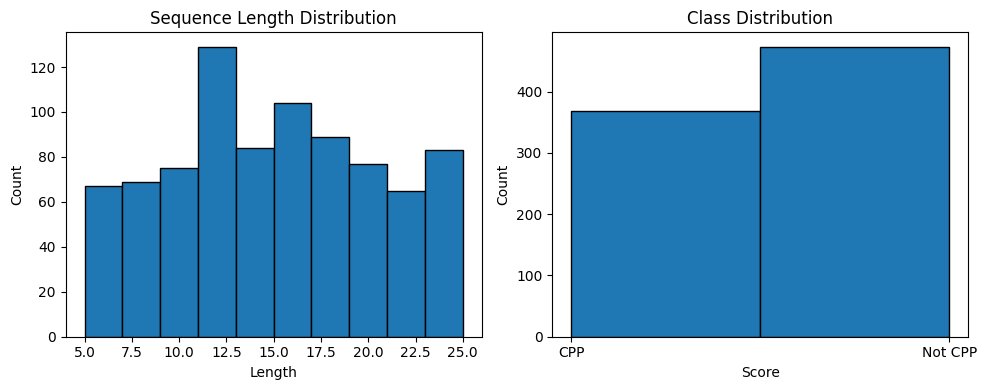

In [49]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

extract_dir = "../../../data/cellppd/raw/"  
out_dir = "../../../data/cellppd/processed/"  

# Load input file
input_file = "cellppd_positive.csv"
file_path = os.path.join(extract_dir, input_file)
df_pos = pd.read_csv(file_path)
input_file = "cellppd_negative.csv"
file_path = os.path.join(extract_dir, input_file)
df_neg = pd.read_csv(file_path)

df_pos["classes"] = "CPP"
df_neg["classes"] = "Not CPP"

df = pd.concat([df_pos, df_neg], ignore_index=True)
df = df[(df["sequence"].str.len() <= 25) & (df["sequence"].str.len() >= 5)].copy()
df["sequence_length"] = [len(i) for i in df["sequence"]]

def deduplicate_sequences_levenshtein(df, seq_col="sequence", max_distance=2):
    keep_mask = []
    kept_sequences = []

    for seq in df[seq_col]:
        is_duplicate = False
        for kept in kept_sequences:
            if levenshtein_distance(seq, kept) <= max_distance:
                is_duplicate = True
                break
        keep_mask.append(not is_duplicate)
        if not is_duplicate:
            kept_sequences.append(seq)

    return df[keep_mask].reset_index(drop=True)

# Remove sequences that are very similar
df = deduplicate_sequences_levenshtein(df)

# Select final columns
final_df = df[
    ["sequence", "sequence_length", "classes"]
].copy()

# Filtering
final_df["sequence"] = final_df["sequence"].str.upper()
final_df = final_df.dropna()
valid_aas = set("ARNDCEQGHILKMFPSTWYV")
final_df = final_df[final_df["sequence"].apply(lambda seq: set(seq).issubset(valid_aas))]
final_df = final_df.drop_duplicates(subset=["sequence"], keep="first")

# Save to Excel
output_file = "cellppd.csv"
file_path = os.path.join(out_dir, output_file)
final_df.to_csv(file_path, index=False)

print(f"Saved cleaned file to: {file_path}")

df = pd.read_csv(file_path)

avg_len = df["sequence"].str.len().mean()
print(f"Number of sequences: {len(df["sequence"]):.1f}")
print(f"Sequence length: {avg_len:.1f}")
print(f"Min length: {np.min(df["sequence_length"]):.1f}")

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.hist(df["sequence"].str.len(), bins=10, edgecolor='black')
plt.title(f"Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")


plt.subplot(1,2,2)
plt.hist(df["classes"], bins=2, edgecolor='black')
plt.title(f"Class Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


## ToxinPred 3.0 - Toxic (positive) and non-toxic peptides (negative)

Saved cleaned file to: ../../../data/toxinpred3/processed/toxinpred3.csv
Number of sequences: 1386.0
Sequence length: 11.4
Min length: 5.0


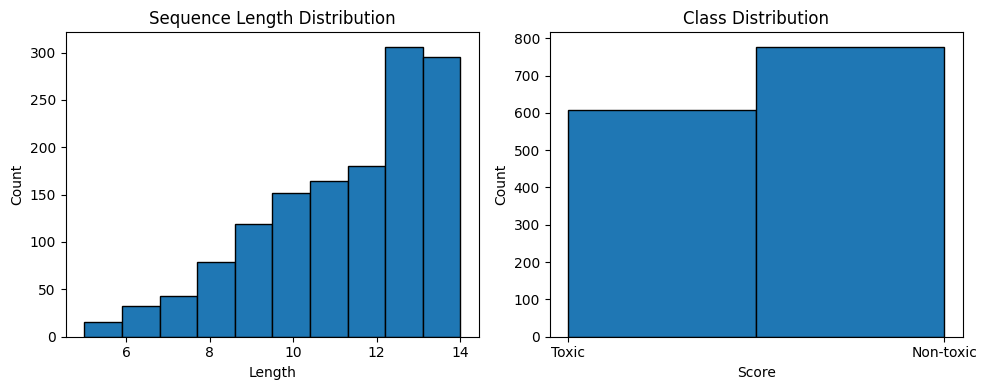

In [51]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

extract_dir = "../../../data/toxinpred3/raw/"  
out_dir = "../../../data/toxinpred3/processed/"  

# Load input file
input_file = "train_pos.csv"
file_path = os.path.join(extract_dir, input_file)
df_pos = pd.read_csv(file_path)
input_file = "train_neg.csv"
file_path = os.path.join(extract_dir, input_file)
df_neg = pd.read_csv(file_path)

df_pos["classes"] = "Toxic"
df_neg["classes"] = "Non-toxic"

df = pd.concat([df_pos, df_neg], ignore_index=True)
df = df[(df["sequence"].str.len() <= 14) & (df["sequence"].str.len() >= 5)].copy()
df["sequence_length"] = [len(i) for i in df["sequence"]]

def deduplicate_sequences_levenshtein(df, seq_col="sequence", max_distance=2):
    keep_mask = []
    kept_sequences = []

    for seq in df[seq_col]:
        is_duplicate = False
        for kept in kept_sequences:
            if levenshtein_distance(seq, kept) <= max_distance:
                is_duplicate = True
                break
        keep_mask.append(not is_duplicate)
        if not is_duplicate:
            kept_sequences.append(seq)

    return df[keep_mask].reset_index(drop=True)

# Remove sequences that are very similar
df = deduplicate_sequences_levenshtein(df)

# Select final columns
final_df = df[
    ["sequence", "sequence_length", "classes"]
].copy()

# Filtering
final_df["sequence"] = final_df["sequence"].str.upper()
final_df = final_df.dropna()
valid_aas = set("ARNDCEQGHILKMFPSTWYV")
final_df = final_df[final_df["sequence"].apply(lambda seq: set(seq).issubset(valid_aas))]
final_df = final_df.drop_duplicates(subset=["sequence"], keep="first")

# Save to Excel
output_file = "toxinpred3.csv"
file_path = os.path.join(out_dir, output_file)
final_df.to_csv(file_path, index=False)

print(f"Saved cleaned file to: {file_path}")

df = pd.read_csv(file_path)

avg_len = df["sequence"].str.len().mean()
print(f"Number of sequences: {len(df["sequence"]):.1f}")
print(f"Sequence length: {avg_len:.1f}")
print(f"Min length: {np.min(df["sequence_length"]):.1f}")

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.hist(df["sequence"].str.len(), bins=10, edgecolor='black')
plt.title(f"Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")


plt.subplot(1,2,2)
plt.hist(df["classes"], bins=2, edgecolor='black')
plt.title(f"Class Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()
